# DSA activity recognition — Adaptive transfer (paper-style comparisons)

This notebook reproduces **part of the experimental story** from *Daily Physical Activity Monitoring: Adaptive Learning from Multi-Source Motion Sensor Data* (Zhang et al.) using **real UCI DSA data** in PyHealth.

## Environment (use the project venv)

From the repo root:

```bash
python3 -m venv .venv   # if you do not already have it
source .venv/bin/activate
pip install -e ".[dev]"   # or your usual PyHealth install
pip install jupyter matplotlib
```

Register this venv as a Jupyter kernel (optional but recommended):

```bash
.venv/bin/python -m ipykernel install --user --name=pyhealth-venv --display-name="PyHealth (.venv)"
```

Then open this notebook and choose the **PyHealth (.venv)** kernel.

**Why:** The repo targets a current Python (3.10+); the system `python3` may be too old for PyHealth’s syntax.

## What is implemented here

- **Domains:** Each on-body unit (`T`, `RA`, `LA`, `RL`, `LL`) is treated as a sensor *domain* with a single-unit input `(125 × 9)`, matching the paper’s multi-source view of DSA.
- **Target domain:** One held-out unit (default `LL`). **Sources:** the other four units.
- **Split:** Subject-level train / val / test via `split_by_patient` semantics (same segment index aligns across units — `sample_id` matches).
- **Model:** `AdaptiveTransferModel` (paper-aligned **LSTM(64)** or optional **`backbone="fcn"`** Conv1D+GAP) + `Trainer`. **Classification:** 19-class DSA activity recognition (AAAI reproducibility plan), not the INFORMS paper’s one-vs-rest binary protocol.
- **IPD:** Configurable via `IPD_BACKEND`: **`dtw_kde`** = paired multivariate DTW + Gaussian KDE (authors’ smooth-bootstrap pattern, `HealthTimeSerial`-style bandwidth); **`embedding`** = faster encoder distances.
- **Paper-aligned comparisons (conceptual):**
  - **No transfer:** train only on the target domain.
  - **Direct transfer:** sequential pre-training on *all* source domains (fixed canonical order), then fine-tune on the target.
  - **Adaptive / IPD-ranked transfer:** rank sources with **Inter-domain Pairwise Distance (IPD)** using a short *probe* model on the target, then pre-train sources in that order with **similarity-scaled learning rates** (`get_adaptive_lr`).
  - **No pairing (ablation):** same pipeline as adaptive, but **random** source order (destroys paired relevance).
- **Ablations (model flags):** KDE smoothing on/off, similarity weighting on/off, distance metric (`euclidean`, `cosine`, `manhattan`).
- **Noise stress test:** Gaussian noise on test inputs (related to robustness claims in the paper).

## Fair comparison note

The public PyHealth model implements **IPD on encoder embeddings** with optional Gaussian smoothing, not the paper’s full DTW + KDE bootstrap pipeline. **Do not expect numerical RCC/accuracy to match the paper tables**; the notebook focuses on *relative* behavior (transfer helps, ranking + LR shaping changes outcomes, ablations move metrics).

## Data path

Default: `HealthTimeSerial/data` under the repository root (same layout as `scripts/dsa_real_data_sample.ipynb`). Adjust `DSA_ROOT` if your tree differs.


In [1]:
from __future__ import annotations

import os
import random
import sys
import warnings
from dataclasses import dataclass
from itertools import chain
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch

warnings.filterwarnings("ignore", category=UserWarning)

# --- Repo root (notebook cwd is usually repo root or examples/) ---
_CWD = Path.cwd().resolve()
if (_CWD / "pyhealth").is_dir():
    REPO_ROOT = _CWD
elif (_CWD.parent / "pyhealth").is_dir():
    REPO_ROOT = _CWD.parent
else:
    raise FileNotFoundError(
        "Run this notebook from the PyHealth repo root or from examples/."
    )
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from pyhealth.datasets import DSADataset, get_dataloader
from pyhealth.datasets.utils import collate_fn_dict_with_padding
from pyhealth.models.adaptive_transfer import AdaptiveTransferModel
from pyhealth.tasks import DSAActivityClassification
from pyhealth.trainer import Trainer

plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
)

print("Python:", sys.executable)
print("Repo root:", REPO_ROOT)


/Users/tomiyoshi/DataspellProjects/PyHealth/.venv-test/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: /Users/tomiyoshi/DataspellProjects/PyHealth/.venv-test/bin/python
Repo root: /Users/tomiyoshi/DataspellProjects/PyHealth


In [2]:
# --- Configuration ---
DSA_ROOT = Path(os.environ.get("DSA_ROOT", REPO_ROOT / "HealthTimeSerial" / "data")).resolve()
TARGET_UNIT = "LL"  # paper-style single-source target
ALL_UNITS = ("T", "RA", "LA", "RL", "LL")
SOURCE_UNITS = tuple(u for u in ALL_UNITS if u != TARGET_UNIT)

SEED = 598
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
BATCH_SIZE = 64
HIDDEN_DIM = 64
NUM_LAYERS = 1
DROPOUT = 0.2

EPOCHS_PROBE = 2
EPOCHS_PRETRAIN_PER_SOURCE = 2
EPOCHS_FINETUNE = 5

# Set True for full ablation grid (slower)
RUN_FULL_ABLATIONS = False

# Paper-style IPD: paired multivariate DTW + Gaussian KDE (see ipd_dtw_kde.py).
# Use "embedding" for encoder-distance IPD (faster).
IPD_BACKEND = "dtw_kde"

if not DSA_ROOT.is_dir():
    raise FileNotFoundError(
        f"DSA_ROOT not found: {DSA_ROOT}\n"
        "Download UCI DSA and place a01…a19 / p1… / sXX.txt under this path, "
        "or set DSA_ROOT in the environment."
    )

print("DSA_ROOT:", DSA_ROOT)
print("TARGET_UNIT:", TARGET_UNIT, "| SOURCES:", SOURCE_UNITS)
print("DEVICE:", DEVICE)


DSA_ROOT: /Users/tomiyoshi/DataspellProjects/PyHealth/HealthTimeSerial/data
TARGET_UNIT: LL | SOURCES: ('T', 'RA', 'LA', 'RL')
DEVICE: mps


In [3]:
def patient_split_indices(
    dataset,
    ratios: Tuple[float, float, float] = (0.5, 0.25, 0.25),
    seed: int = SEED,
) -> Dict[str, List[int]]:
    rng = np.random.default_rng(seed)
    patient_ids = list(dataset.patient_to_index.keys())
    rng.shuffle(patient_ids)
    n = len(patient_ids)
    n_train = int(n * ratios[0])
    n_val = int(n * ratios[1])
    train_p = patient_ids[:n_train]
    val_p = patient_ids[n_train : n_train + n_val]
    test_p = patient_ids[n_train + n_val :]

    def expand(patients):
        return list(chain(*[dataset.patient_to_index[pid] for pid in patients]))

    return {
        "train": expand(train_p),
        "val": expand(val_p),
        "test": expand(test_p),
        "train_patients": train_p,
        "val_patients": val_p,
        "test_patients": test_p,
    }


def subset_dataset(ds, indices: Sequence[int]):
    return ds.subset(list(indices))


@dataclass
class DomainBundle:
    unit: str
    full: object
    train: object
    val: object
    test: object


def build_domain_datasets(
    base: DSADataset,
    root: Path,
    units: Sequence[str],
    split: Dict[str, List[int]],
    num_workers: int = 1,
) -> Dict[str, DomainBundle]:
    out: Dict[str, DomainBundle] = {}
    for u in units:
        task = DSAActivityClassification(
            dataset_root=str(root),
            selected_units=(u,),
        )
        full = base.set_task(task, num_workers=num_workers)
        out[u] = DomainBundle(
            unit=u,
            full=full,
            train=subset_dataset(full, split["train"]),
            val=subset_dataset(full, split["val"]),
            test=subset_dataset(full, split["test"]),
        )
    return out


def make_loaders(train_ds, val_ds, test_ds, batch_size: int = BATCH_SIZE):
    train_loader = get_dataloader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = get_dataloader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = get_dataloader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


def collate_indices(ds, indices: Sequence[int], batch_size: int) -> List[Dict]:
    out = []
    for i in range(0, len(indices), batch_size):
        chunk = indices[i : i + batch_size]
        rows = [ds[j] for j in chunk]
        out.append(collate_fn_dict_with_padding(rows))
    return out


def mean_ipd_between(
    model: AdaptiveTransferModel,
    ds_src,
    ds_tgt,
    val_indices: Sequence[int],
    batch_size: int = 64,
) -> float:
    model.eval()
    batches_src = collate_indices(ds_src, val_indices, batch_size)
    batches_tgt = collate_indices(ds_tgt, val_indices, batch_size)
    vals = []
    for a, b in zip(batches_src, batches_tgt):
        vals.append(model.compute_ipd(a, b))
    return float(np.mean(vals))


def ipd_similarity_matrix(
    probe: AdaptiveTransferModel,
    bundles: Dict[str, DomainBundle],
    units: Sequence[str],
    val_indices: Sequence[int],
) -> np.ndarray:
    n = len(units)
    mat = np.zeros((n, n), dtype=np.float64)
    for i, ui in enumerate(units):
        for j, uj in enumerate(units):
            if i == j:
                mat[i, j] = 0.0
            else:
                mat[i, j] = mean_ipd_between(
                    probe,
                    bundles[ui].full,
                    bundles[uj].full,
                    val_indices,
                )
    return mat


def train_with_trainer(
    model: AdaptiveTransferModel,
    train_loader,
    val_loader,
    epochs: int,
    lr: float,
    monitor: Optional[str] = "accuracy",
) -> None:
    trainer = Trainer(
        model=model,
        device=DEVICE,
        metrics=["accuracy"],
        enable_logging=False,
    )
    trainer.train(
        train_dataloader=train_loader,
        val_dataloader=val_loader,
        epochs=epochs,
        optimizer_params={"lr": lr},
        monitor=monitor,
        load_best_model_at_last=False,
    )


def evaluate_accuracy(model: AdaptiveTransferModel, test_loader) -> float:
    trainer = Trainer(
        model=model,
        device=DEVICE,
        metrics=["accuracy"],
        enable_logging=False,
    )
    scores = trainer.evaluate(test_loader)
    return float(scores["accuracy"])


def add_gaussian_noise(batch: dict, std: float) -> dict:
    if std <= 0:
        return batch
    out = dict(batch)
    sig = out["signal"]
    if isinstance(sig, torch.Tensor):
        out["signal"] = sig + torch.randn_like(sig) * std
    return out


def accuracy_under_noise(
    model: AdaptiveTransferModel, test_loader, noise_stds: Sequence[float]
) -> List[float]:
    model.eval()
    results = []
    for std in noise_stds:
        ys, ps = [], []
        for data in test_loader:
            data = {k: (v.to(DEVICE) if isinstance(v, torch.Tensor) else v) for k, v in data.items()}
            data = add_gaussian_noise(data, std)
            with torch.no_grad():
                out = model(**data)
            ys.append(out["y_true"].cpu().numpy())
            ps.append(out["y_prob"].cpu().numpy())
        y = np.concatenate(ys)
        p = np.concatenate(ps)
        from pyhealth.metrics import multiclass_metrics_fn

        scores = multiclass_metrics_fn(y, p, metrics=["accuracy"])
        results.append(float(scores["accuracy"]))
    return results


## INFORMS paper protocol on DSA (binary one-vs-rest, **with IPD**)

This block matches the **Zhang et al. (INFORMS)** DSA setup in `main.tex` **before** the multiclass AAAI experiments below.

**Why it appears here:** the binary task only needs `DSADataset` + relabeling; it does **not** depend on the multiclass `bundles` object. It **does** use the same **`IPD_BACKEND`** as the rest of the notebook (`dtw_kde` = paired multivariate DTW + KDE, or `embedding` = encoder distances; embedding IPD gets a **1-epoch target probe** so rankings are meaningful).

**Protocol:** 6 subjects train / 2 validation; random activity as **positive** (one-vs-rest); **balanced** training (bootstrap) and **balanced** validation (downsample); **RCC** = accuracy on balanced val.

**Comparisons (per repetition):**

1. **No transfer** — train only on the **target** sensor; epoch budget matches total gradient budget of the transfer runs (all steps on target data).
2. **Direct transfer** — sequential pretrain on **each source** sensor (fixed canonical order), equal LR, then target finetune.
3. **Adaptive IPD** — sources ordered by **lower IPD to target** (mean over training segments); pretrain with **`get_adaptive_lr`** similarity scaling, then finetune.

The next code cell prints per-run RCC and shows a **bar chart** (mean ± std over repetitions).



No config path provided, using default config
Initializing dsa dataset from /Users/tomiyoshi/DataspellProjects/PyHealth/HealthTimeSerial/data (dev mode: False)
No cache_dir provided. Using default cache dir: /Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0
Setting task DSAActivityClassification for dsa base dataset...
Task cache paths: task_df=/Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/task_df.ld, samples=/Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at /Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld, skipping processing.
Setting task

Epoch 0 / 8: 100%|██████████| 810/810 [00:09<00:00, 82.85it/s]

--- Train epoch-0, step-810 ---
loss: 0.6007



Evaluation: 100%|██████████| 15/15 [00:00<00:00, 176.24it/s]

--- Eval epoch-0, step-810 ---
accuracy: 0.6458
loss: 0.6100
New best accuracy score (0.6458) at epoch-0, step-810



...

--- Train epoch-5, step-4860 ---
loss: 0.2668



Evaluation: 100%|██████████| 15/15 [00:00<00:00, 174.08it/s]

--- Eval epoch-5, step-4860 ---
accuracy: 0.8000
loss: 0.5447
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 15/15 [00:00<00:00, 114.09it/s]


rep 4 adaptive_ipd: pos=A04 RCC=0.8000 | IPD rank: ['RA', 'RL', 'LA', 'T']


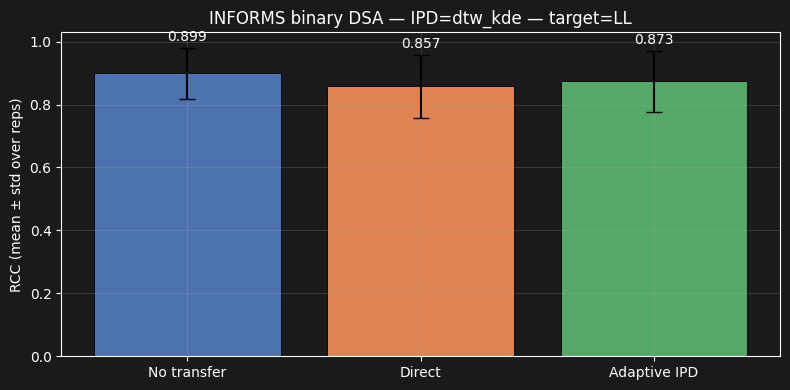

Summary (INFORMS binary): {'no_transfer': (np.float64(0.8991666666666667), np.float64(0.081325819325039)), 'direct_transfer': (np.float64(0.8574999999999999), np.float64(0.10118739491107025)), 'adaptive_ipd': (np.float64(0.8733333333333333), np.float64(0.0975605225260482))}


In [4]:
from pyhealth.datasets import create_sample_dataset

# --- INFORMS binary DSA + IPD-ranked transfer (matches paper task; uses IPD_BACKEND) ---
INFORMS_TRAIN_SUBJECTS = 6
BINARY_REPS = 5  # paper uses 15
EPOCHS_PRETRAIN_INFORMS = 2
EPOCHS_FINETUNE_INFORMS = 6
BINARY_BATCH = 16
MAX_IPD_TRAIN_SAMPLES = 350  # subsample training segments for DTW IPD speed
PROBE_EMBEDDING_EPOCHS = 1  # only if IPD_BACKEND == "embedding"


def informs_subject_split(
    all_subjects: Sequence[str],
    n_train: int,
    seed: int,
) -> Tuple[set, set]:
    rng = np.random.default_rng(seed)
    ids = list(all_subjects)
    rng.shuffle(ids)
    train_s = set(ids[:n_train])
    val_s = set(ids[n_train:])
    return train_s, val_s


def samples_for_subjects(
    sample_ds,
    subjects: set,
    positive_class: int,
) -> List[dict]:
    rows: List[dict] = []
    for i in range(len(sample_ds)):
        s = sample_ds[i]
        pid = s["patient_id"]
        if isinstance(pid, bytes):
            pid = pid.decode()
        if pid not in subjects:
            continue
        sig = s["signal"]
        if hasattr(sig, "detach"):
            sig = sig.cpu().float().numpy()
        y = int(s["label"].item()) if hasattr(s["label"], "item") else int(s["label"])
        y_bin = 1 if y == positive_class else 0
        rows.append(
            {
                "patient_id": pid,
                "visit_id": str(s.get("sample_id", f"s{i}")),
                "signal": sig,
                "label": y_bin,
            }
        )
    return rows


def balance_train_bootstrap(
    samples: List[dict], rng: np.random.Generator
) -> List[dict]:
    pos = [s for s in samples if s["label"] == 1]
    neg = [s for s in samples if s["label"] == 0]
    if not pos or not neg:
        return samples
    if len(pos) < len(neg):
        idx = rng.integers(0, len(pos), size=len(neg))
        pos = [dict(pos[i]) for i in idx]
    elif len(neg) < len(pos):
        idx = rng.integers(0, len(neg), size=len(pos))
        neg = [dict(neg[i]) for i in idx]
    out = pos + neg
    rng.shuffle(out)
    return out


def balance_val_downsample_neg(
    samples: List[dict], rng: np.random.Generator
) -> List[dict]:
    pos = [s for s in samples if s["label"] == 1]
    neg = [s for s in samples if s["label"] == 0]
    if not pos or not neg:
        return samples
    n = min(len(pos), len(neg))
    rng.shuffle(pos)
    rng.shuffle(neg)
    out = pos[:n] + neg[:n]
    rng.shuffle(out)
    return out


def indices_on_patients(sample_ds, subjects: set) -> List[int]:
    idx: List[int] = []
    for i in range(len(sample_ds)):
        pid = sample_ds[i]["patient_id"]
        if isinstance(pid, bytes):
            pid = pid.decode()
        if pid in subjects:
            idx.append(i)
    return idx


def mean_ipd_train_segments(
    ipd_model: AdaptiveTransferModel,
    ds_src,
    ds_tgt,
    train_indices: Sequence[int],
    batch_size: int = 48,
) -> float:
    vals: List[float] = []
    for i in range(0, len(train_indices), batch_size):
        chunk = list(train_indices[i : i + batch_size])
        rows_s = [ds_src[j] for j in chunk]
        rows_t = [ds_tgt[j] for j in chunk]
        ba = collate_fn_dict_with_padding(rows_s)
        bb = collate_fn_dict_with_padding(rows_t)
        vals.append(ipd_model.compute_ipd(ba, bb))
    return float(np.mean(vals))


def build_binary_sample_dataset(raw: List[dict], name: str):
    return create_sample_dataset(
        samples=raw,
        input_schema={"signal": "tensor"},
        output_schema={"label": "multiclass"},
        dataset_name=name,
        in_memory=True,
    )


base_informs = DSADataset(root=str(DSA_ROOT), num_workers=1)
ds_by_unit: Dict[str, object] = {}
for u in ALL_UNITS:
    ds_by_unit[u] = base_informs.set_task(
        DSAActivityClassification(
            dataset_root=str(DSA_ROOT),
            selected_units=(u,),
        ),
        num_workers=1,
    )
all_subjects = sorted(ds_by_unit[TARGET_UNIT].patient_to_index.keys())
assert len(all_subjects) == 8, f"Expected 8 DSA subjects, got {len(all_subjects)}"

informs_results: Dict[str, List[float]] = {
    "no_transfer": [],
    "direct_transfer": [],
    "adaptive_ipd": [],
}

for rep in range(BINARY_REPS):
    rng = np.random.default_rng(SEED + rep * 997)
    train_subj, val_subj = informs_subject_split(
        all_subjects, INFORMS_TRAIN_SUBJECTS, seed=SEED + rep * 13
    )
    pos_class = int(rng.integers(0, 19))

    train_ds_u: Dict[str, object] = {}
    val_ds_u: Dict[str, object] = {}
    for u in ALL_UNITS:
        raw_tr = samples_for_subjects(ds_by_unit[u], train_subj, pos_class)
        raw_va = samples_for_subjects(ds_by_unit[u], val_subj, pos_class)
        raw_tr = balance_train_bootstrap(raw_tr, rng)
        raw_va = balance_val_downsample_neg(raw_va, rng)
        if not raw_tr or not raw_va:
            train_ds_u[u] = None
            val_ds_u[u] = None
            continue
        train_ds_u[u] = build_binary_sample_dataset(
            raw_tr, f"informs_tr_{rep}_{u}"
        )
        val_ds_u[u] = build_binary_sample_dataset(
            raw_va, f"informs_va_{rep}_{u}"
        )

    if any(train_ds_u[u] is None for u in ALL_UNITS):
        print(f"rep {rep}: skip (empty domain); pos=A{pos_class + 1:02d}")
        continue

    idx_ipd = indices_on_patients(ds_by_unit[TARGET_UNIT], train_subj)
    rng.shuffle(idx_ipd)
    idx_ipd = idx_ipd[: min(len(idx_ipd), MAX_IPD_TRAIN_SAMPLES)]

    ipd_model = AdaptiveTransferModel(
        dataset=train_ds_u[TARGET_UNIT],
        feature_key="signal",
        hidden_dim=64,
        num_layers=1,
        dropout=0.2,
        backbone="lstm",
        ipd_backend=IPD_BACKEND,
        distance_fn="euclidean",
        use_similarity_weighting=True,
        use_kde_smoothing=True,
        kde_bandwidth=7.8,
        kde_n_draws=10,
        kde_random_state=SEED + rep,
    ).to(DEVICE)

    if IPD_BACKEND == "embedding":
        train_with_trainer(
            ipd_model,
            get_dataloader(train_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=True),
            get_dataloader(val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False),
            epochs=PROBE_EMBEDDING_EPOCHS,
            lr=1e-3,
            monitor="accuracy",
        )

    ipd_src_to_tgt: Dict[str, float] = {}
    for s in SOURCE_UNITS:
        ipd_src_to_tgt[s] = mean_ipd_train_segments(
            ipd_model, ds_by_unit[s], ds_by_unit[TARGET_UNIT], idx_ipd
        )
    ranked_sources = sorted(SOURCE_UNITS, key=lambda u: ipd_src_to_tgt[u])
    canonical_sources = list(SOURCE_UNITS)

    total_target_epochs = EPOCHS_PRETRAIN_INFORMS + EPOCHS_FINETUNE_INFORMS
    base_lr = 5e-3

    for mode in ("no_transfer", "direct_transfer", "adaptive_ipd"):
        model = AdaptiveTransferModel(
            dataset=train_ds_u[TARGET_UNIT],
            feature_key="signal",
            hidden_dim=64,
            num_layers=1,
            dropout=0.2,
            backbone="lstm",
            ipd_backend=IPD_BACKEND,
            kde_random_state=SEED + rep,
            use_similarity_weighting=(mode == "adaptive_ipd"),
            use_kde_smoothing=True,
        ).to(DEVICE)

        if mode == "no_transfer":
            train_with_trainer(
                model,
                get_dataloader(train_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=True),
                get_dataloader(val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False),
                epochs=total_target_epochs,
                lr=base_lr,
                monitor="accuracy",
            )
        elif mode == "direct_transfer":
            for s in canonical_sources:
                train_with_trainer(
                    model,
                    get_dataloader(train_ds_u[s], batch_size=BINARY_BATCH, shuffle=True),
                    get_dataloader(val_ds_u[s], batch_size=BINARY_BATCH, shuffle=False),
                    epochs=EPOCHS_PRETRAIN_INFORMS,
                    lr=base_lr,
                    monitor="accuracy",
                )
            train_with_trainer(
                model,
                get_dataloader(train_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=True),
                get_dataloader(val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False),
                epochs=EPOCHS_FINETUNE_INFORMS,
                lr=base_lr,
                monitor="accuracy",
            )
        else:
            for s in ranked_sources:
                sim = 1.0 / (ipd_src_to_tgt[s] + 1e-8)
                lr = model.get_adaptive_lr(base_lr, sim)
                train_with_trainer(
                    model,
                    get_dataloader(train_ds_u[s], batch_size=BINARY_BATCH, shuffle=True),
                    get_dataloader(val_ds_u[s], batch_size=BINARY_BATCH, shuffle=False),
                    epochs=EPOCHS_PRETRAIN_INFORMS,
                    lr=lr,
                    monitor="accuracy",
                )
            train_with_trainer(
                model,
                get_dataloader(train_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=True),
                get_dataloader(val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False),
                epochs=EPOCHS_FINETUNE_INFORMS,
                lr=base_lr,
                monitor="accuracy",
            )

        acc = evaluate_accuracy(
            model,
            get_dataloader(val_ds_u[TARGET_UNIT], batch_size=BINARY_BATCH, shuffle=False),
        )
        informs_results[mode].append(acc)
        print(
            f"rep {rep} {mode}: pos=A{pos_class + 1:02d} RCC={acc:.4f} | "
            f"IPD rank: {ranked_sources}"
        )

# --- Comparison chart ---
labels_short = ["No transfer", "Direct", "Adaptive IPD"]
keys = ["no_transfer", "direct_transfer", "adaptive_ipd"]
means = [float(np.mean(informs_results[k])) if informs_results[k] else 0.0 for k in keys]
stds = [float(np.std(informs_results[k])) if informs_results[k] else 0.0 for k in keys]
xpos = np.arange(len(keys))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    xpos,
    means,
    yerr=stds,
    capsize=6,
    color=["#4c72b0", "#dd8452", "#55a868"],
    edgecolor="black",
    linewidth=0.6,
)
ax.set_xticks(xpos)
ax.set_xticklabels(labels_short)
ax.set_ylabel("RCC (mean ± std over reps)")
ax.set_title(
    f"INFORMS binary DSA — IPD={IPD_BACKEND} — target={TARGET_UNIT}"
)
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.02, f"{m:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

print("Summary (INFORMS binary):", {k: (np.mean(v), np.std(v)) for k, v in informs_results.items() if v})

del base_informs, ds_by_unit



In [5]:
# Load base DSA once; task-specific caches are separate per unit.
base_dsa = DSADataset(root=str(DSA_ROOT), num_workers=1)

template_task = DSAActivityClassification(
    dataset_root=str(DSA_ROOT),
    selected_units=(ALL_UNITS[0],),
)
template_full = base_dsa.set_task(template_task, num_workers=1)
split = patient_split_indices(template_full, seed=SEED)
bundles = build_domain_datasets(base_dsa, DSA_ROOT, ALL_UNITS, split, num_workers=1)

val_idx = split["val"]
tgt = bundles[TARGET_UNIT]

# sanity: aligned sample_id across units
for u in ALL_UNITS:
    for i in (0, 1000, 9000):
        assert bundles[u].full[i]["sample_id"] == bundles[ALL_UNITS[0]].full[i]["sample_id"]
print("Sample alignment OK across domains.")
print("Train/val/test sizes:", len(split["train"]), len(val_idx), len(split["test"]))


No config path provided, using default config
Initializing dsa dataset from /Users/tomiyoshi/DataspellProjects/PyHealth/HealthTimeSerial/data (dev mode: False)
No cache_dir provided. Using default cache dir: /Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0
Setting task DSAActivityClassification for dsa base dataset...
Task cache paths: task_df=/Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/task_df.ld, samples=/Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld
Found cached processed samples at /Users/tomiyoshi/Library/Caches/pyhealth/1743f6fe-e4e7-5ea3-b179-3f09df09a3d0/tasks/DSAActivityClassification_1f8bbaa9-1cde-54a3-9e64-7b9054eb5fe3/samples_cdbbc602-34e2-5a41-8643-4c76b08829f6.ld, skipping processing.
Setting task

AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.001}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x14065e050>
Monitor: accuracy
Monitor criterion: max
Epochs: 2
Patience: None



Epoch 0 / 2: 100%|██████████| 72/72 [00:01<00:00, 58.71it/s]

--- Train epoch-0, step-72 ---
loss: 2.9136



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 123.26it/s]

--- Eval epoch-0, step-72 ---
accuracy: 0.1303
loss: 2.7989
New best accuracy score (0.1303) at epoch-0, step-72




Epoch 1 / 2: 100%|██████████| 72/72 [00:01<00:00, 62.39it/s]

--- Train epoch-1, step-144 ---
loss: 2.5525



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 148.42it/s]

--- Eval epoch-1, step-144 ---
accuracy: 0.1763
loss: 2.5076
New best accuracy score (0.1763) at epoch-1, step-144


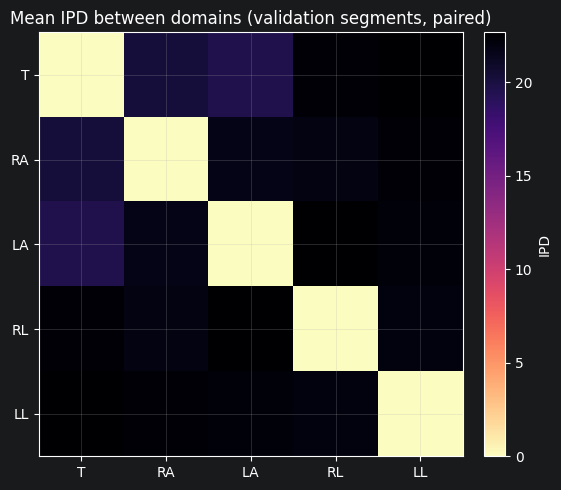

Sources ranked by similarity to target (low IPD first): ['RL', 'LA', 'RA', 'T']
IPD to target: {'T': 22.643, 'RA': 22.4776, 'LA': 22.3177, 'RL': 22.0352}


In [6]:
# --- Probe model: short target-only training so IPD reflects task-relevant geometry ---
probe_ds = tgt.train
probe_train_loader, probe_val_loader, _ = make_loaders(
    probe_ds, bundles[TARGET_UNIT].val, bundles[TARGET_UNIT].test
)

probe = AdaptiveTransferModel(
    dataset=probe_ds,
    feature_key="signal",
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    backbone="lstm",
    distance_fn="euclidean",
    ipd_backend=IPD_BACKEND,
    kde_bandwidth=7.8,
    kde_n_draws=10,
    kde_random_state=SEED,
    use_similarity_weighting=True,
    use_kde_smoothing=True,
).to(DEVICE)

train_with_trainer(
    probe,
    probe_train_loader,
    probe_val_loader,
    epochs=EPOCHS_PROBE,
    lr=1e-3,
)

ipd_mat = ipd_similarity_matrix(probe, bundles, ALL_UNITS, val_idx)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(ipd_mat, cmap="magma_r")
ax.set_xticks(range(len(ALL_UNITS)))
ax.set_yticks(range(len(ALL_UNITS)))
ax.set_xticklabels(ALL_UNITS)
ax.set_yticklabels(ALL_UNITS)
ax.set_title("Mean IPD between domains (validation segments, paired)")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="IPD")
plt.tight_layout()
plt.show()

# Similarities from each source to target (lower IPD => more similar)
src_to_tgt = {
    s: mean_ipd_between(probe, bundles[s].full, bundles[TARGET_UNIT].full, val_idx)
    for s in SOURCE_UNITS
}
ranked_sources = sorted(SOURCE_UNITS, key=lambda u: src_to_tgt[u])
print("Sources ranked by similarity to target (low IPD first):", ranked_sources)
print("IPD to target:", {k: round(v, 4) for k, v in src_to_tgt.items()})


=== no_transfer ===
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.001}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x13fe0b650>
Monitor: accuracy
Monitor criterion: max
Epochs: 13
Patience: None



Epoch 0 / 13: 100%|██████████| 72/72 [00:01<00:00, 63.12it/s]

--- Train epoch-0, step-72 ---
loss: 2.9004



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 164.50it/s]

--- Eval epoch-0, step-72 ---
accuracy: 0.1118
loss: 2.7940
New best accuracy score (0.1118) at epoch-0, step-72



...

--- Train epoch-4, step-360 ---
loss: 2.1799



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 127.91it/s]

--- Eval epoch-4, step-360 ---
accuracy: 0.2886
loss: 2.2419
New best accuracy score (0.2886) at epoch-4, step-360
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 36/36 [00:00<00:00, 136.92it/s]


test accuracy: 0.2917


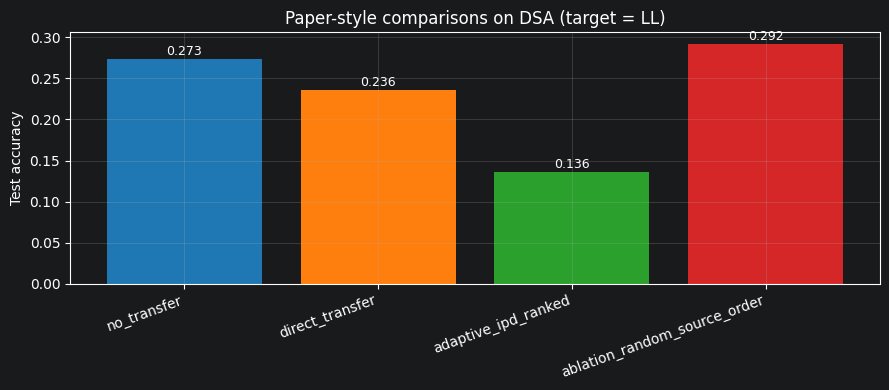

In [7]:
@dataclass
class TrainConfig:
    name: str
    pretrain_order: List[str]
    use_adaptive_lr: bool
    base_lr: float = 1e-3
    model_distance: str = "euclidean"
    use_kde_smoothing: bool = True
    use_similarity_weighting: bool = True


def run_experiment(cfg: TrainConfig) -> float:
    target_train = bundles[TARGET_UNIT].train
    target_val = bundles[TARGET_UNIT].val
    target_test = bundles[TARGET_UNIT].test
    tr_l, va_l, te_l = make_loaders(target_train, target_val, target_test)

    model = AdaptiveTransferModel(
        dataset=target_train,
        feature_key="signal",
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        backbone="lstm",
        distance_fn=cfg.model_distance,
        ipd_backend=IPD_BACKEND,
        kde_random_state=SEED,
        use_similarity_weighting=cfg.use_similarity_weighting,
        use_kde_smoothing=cfg.use_kde_smoothing,
    ).to(DEVICE)

    if cfg.name == "no_transfer":
        total_epochs = EPOCHS_PRETRAIN_PER_SOURCE * len(SOURCE_UNITS) + EPOCHS_FINETUNE
        train_with_trainer(model, tr_l, va_l, epochs=total_epochs, lr=cfg.base_lr)
        return evaluate_accuracy(model, te_l)

    for src in cfg.pretrain_order:
        src_train = bundles[src].train
        s_tr, s_va, _ = make_loaders(src_train, bundles[src].val, bundles[src].test)
        sim = 1.0 / (mean_ipd_between(probe, bundles[src].full, bundles[TARGET_UNIT].full, val_idx) + 1e-8)
        lr = (
            model.get_adaptive_lr(cfg.base_lr, sim)
            if cfg.use_adaptive_lr
            else cfg.base_lr
        )
        train_with_trainer(
            model,
            s_tr,
            s_va,
            epochs=EPOCHS_PRETRAIN_PER_SOURCE,
            lr=lr,
        )

    train_with_trainer(model, tr_l, va_l, epochs=EPOCHS_FINETUNE, lr=cfg.base_lr)
    return evaluate_accuracy(model, te_l)


canonical_source_order = list(SOURCE_UNITS)
random_order = canonical_source_order.copy()
random.Random(SEED).shuffle(random_order)

main_experiments = [
    TrainConfig("no_transfer", [], False),
    TrainConfig(
        "direct_transfer",
        canonical_source_order,
        use_adaptive_lr=False,
    ),
    TrainConfig(
        "adaptive_ipd_ranked",
        ranked_sources,
        use_adaptive_lr=True,
    ),
    TrainConfig(
        "ablation_random_source_order",
        random_order,
        use_adaptive_lr=True,
    ),
]

results_main = {}
for cfg in main_experiments:
    print("===", cfg.name, "===")
    acc = run_experiment(cfg)
    results_main[cfg.name] = acc
    print(f"test accuracy: {acc:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
names = list(results_main.keys())
accs = [results_main[k] for k in names]
xpos = np.arange(len(names))
_cmap = plt.get_cmap("tab10")
ax.bar(xpos, accs, color=[_cmap(i % 10) for i in range(len(names))])
ax.set_xticks(xpos)
ax.set_ylabel("Test accuracy")
ax.set_title("Paper-style comparisons on DSA (target = " + TARGET_UNIT + ")")
ax.set_xticklabels(names, rotation=20, ha="right")
for i, v in enumerate(accs):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()


=== ablation: adaptive_default ===
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 4.538183368270578e-05}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x141cd0550>
Monitor: accuracy
Monitor criterion: max
Epochs: 2
Patience: None



Epoch 0 / 2: 100%|██████████| 72/72 [00:01<00:00, 62.44it/s]

--- Train epoch-0, step-72 ---
loss: 2.9462



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 161.11it/s]

--- Eval epoch-0, step-72 ---
accuracy: 0.0390
loss: 2.9457
New best accuracy score (0.0390) at epoch-0, step-72



...

--- Train epoch-4, step-360 ---
loss: 2.6520



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 147.79it/s]

--- Eval epoch-4, step-360 ---
accuracy: 0.1088
loss: 2.7953
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps




Evaluation: 100%|██████████| 36/36 [00:00<00:00, 128.04it/s]


accuracy: 0.11929824561403508


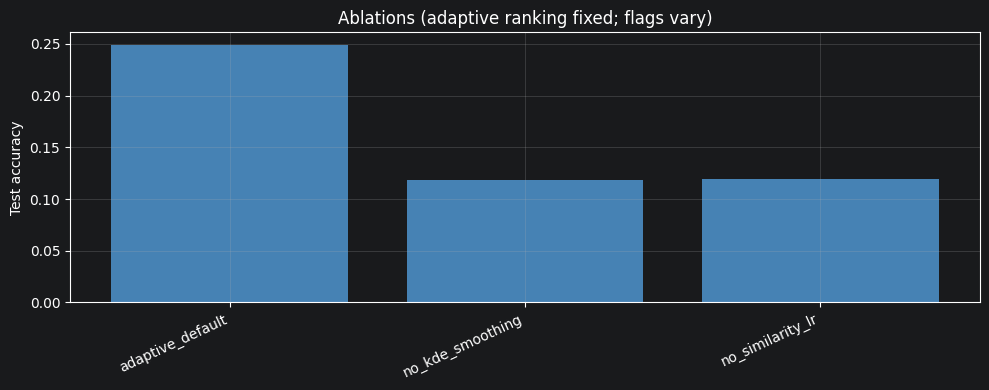

In [8]:
# --- Ablations on AdaptiveTransferModel flags (IPD-ranked pipeline) ---
ablation_configs = [
    ("adaptive_default", "euclidean", True, True),
    ("no_kde_smoothing", "euclidean", True, False),
    ("no_similarity_lr", "euclidean", False, True),
    ("distance_cosine", "cosine", True, True),
    ("distance_manhattan", "manhattan", True, True),
]

if not RUN_FULL_ABLATIONS:
    ablation_configs = ablation_configs[:3]

results_ab = {}
for name, dist, sim_w, kde in ablation_configs:
    cfg = TrainConfig(
        name=name,
        pretrain_order=ranked_sources,
        use_adaptive_lr=sim_w,
        model_distance=dist,
        use_kde_smoothing=kde,
        use_similarity_weighting=sim_w,
    )
    print("=== ablation:", name, "===")
    results_ab[name] = run_experiment(cfg)
    print("accuracy:", results_ab[name])

fig, ax = plt.subplots(figsize=(10, 4))
keys = list(results_ab.keys())
vals = [results_ab[k] for k in keys]
xpos = np.arange(len(keys))
ax.bar(xpos, vals, color="steelblue")
ax.set_xticks(xpos)
ax.set_ylabel("Test accuracy")
ax.set_title("Ablations (adaptive ranking fixed; flags vary)")
ax.set_xticklabels(keys, rotation=25, ha="right")
plt.tight_layout()
plt.show()


Training model for noise curve: no_transfer …
AdaptiveTransferModel(
  (encoder): LSTM(9, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (classifier): Linear(in_features=64, out_features=19, bias=True)
)
Metrics: ['accuracy']
Device: mps

Training:
Batch size: 64
Optimizer: <class 'torch.optim.adam.Adam'>
Optimizer params: {'lr': 0.001}
Weight decay: 0.0
Max grad norm: None
Val dataloader: <torch.utils.data.dataloader.DataLoader object at 0x14065e150>
Monitor: accuracy
Monitor criterion: max
Epochs: 13
Patience: None



Epoch 0 / 13: 100%|██████████| 72/72 [00:01<00:00, 55.48it/s]

--- Train epoch-0, step-72 ---
loss: 2.9089



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 151.17it/s]

--- Eval epoch-0, step-72 ---
accuracy: 0.1268
loss: 2.7541
New best accuracy score (0.1268) at epoch-0, step-72



...

--- Eval epoch-3, step-288 ---
accuracy: 0.1772
loss: 2.5456
New best accuracy score (0.1772) at epoch-3, step-288




Epoch 4 / 5: 100%|██████████| 72/72 [00:01<00:00, 61.14it/s]

--- Train epoch-4, step-360 ---
loss: 2.4686



Evaluation: 100%|██████████| 36/36 [00:00<00:00, 160.54it/s]

--- Eval epoch-4, step-360 ---
accuracy: 0.1895
loss: 2.4544
New best accuracy score (0.1895) at epoch-4, step-360


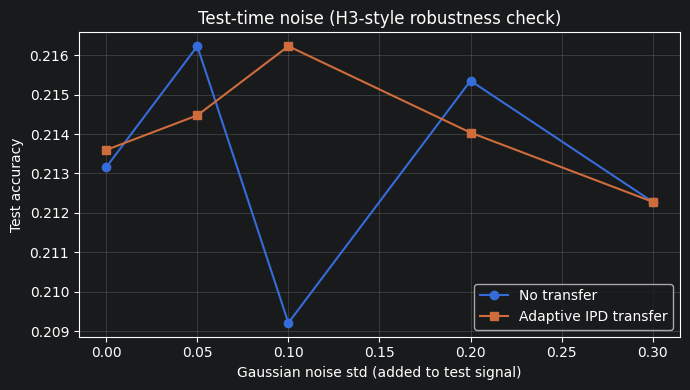

In [9]:
# --- Noise robustness (best main config vs no transfer) ---
# Re-train two fresh models and sweep test-time noise

def train_model_for_noise(mode: str) -> AdaptiveTransferModel:
    target_train = bundles[TARGET_UNIT].train
    target_val = bundles[TARGET_UNIT].val
    tr_l, va_l, _ = make_loaders(target_train, target_val, target_test)
    model = AdaptiveTransferModel(
        dataset=target_train,
        feature_key="signal",
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        backbone="lstm",
        ipd_backend=IPD_BACKEND,
        kde_random_state=SEED,
    ).to(DEVICE)
    if mode == "no_transfer":
        total_epochs = EPOCHS_PRETRAIN_PER_SOURCE * len(SOURCE_UNITS) + EPOCHS_FINETUNE
        train_with_trainer(model, tr_l, va_l, epochs=total_epochs, lr=1e-3)
        return model
    for src in ranked_sources:
        src_train = bundles[src].train
        s_tr, s_va, _ = make_loaders(src_train, bundles[src].val, bundles[src].test)
        sim = 1.0 / (mean_ipd_between(probe, bundles[src].full, bundles[TARGET_UNIT].full, val_idx) + 1e-8)
        lr = model.get_adaptive_lr(1e-3, sim)
        train_with_trainer(model, s_tr, s_va, epochs=EPOCHS_PRETRAIN_PER_SOURCE, lr=lr)
    train_with_trainer(model, tr_l, va_l, epochs=EPOCHS_FINETUNE, lr=1e-3)
    return model


target_test = bundles[TARGET_UNIT].test
_, _, test_loader_noise = make_loaders(
    bundles[TARGET_UNIT].train,
    bundles[TARGET_UNIT].val,
    target_test,
)

noise_levels = [0.0, 0.05, 0.1, 0.2, 0.3]
print("Training model for noise curve: no_transfer …")
m0 = train_model_for_noise("no_transfer")
acc0 = accuracy_under_noise(m0, test_loader_noise, noise_levels)

print("Training model for noise curve: adaptive_ipd …")
m1 = train_model_for_noise("adaptive_ipd")
acc1 = accuracy_under_noise(m1, test_loader_noise, noise_levels)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(noise_levels, acc0, marker="o", label="No transfer")
ax.plot(noise_levels, acc1, marker="s", label="Adaptive IPD transfer")
ax.set_xlabel("Gaussian noise std (added to test signal)")
ax.set_ylabel("Test accuracy")
ax.set_title("Test-time noise (H3-style robustness check)")
ax.legend()
plt.tight_layout()
plt.show()


## References

- Barshan & Altun (2010). Daily and Sports Activities. UCI ML Repository.
- Zhang et al., *Daily Physical Activity Monitoring: Adaptive Learning from Multi-Source Motion Sensor Data* (paper under reproduction in DL4H / PyHealth).
- PyHealth: https://pyhealth.readthedocs.io/
